# Iterative HAL-TMLE for Right-Censored Survival

This notebook prototypes an iterative pointwise TMLE for right-censored survival before we promote the workflow into the package API.

The design choices in this demo are:
- keep the Stage 1 IPCW HAL initializer unchanged;
- keep one fixed augmented grid for each target time `t0`;
- carry a mutable pointwise state forward after each local tilt;
- recompute the least favorable direction at the updated fit;
- stop on the empirical EIF mean rather than only the inner score equation.

In [1]:
import os
import sys
import pathlib
from dataclasses import dataclass
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = pathlib.Path.cwd().resolve()
for candidate in [ROOT, ROOT.parent, ROOT.parent.parent]:
    src_path = candidate / 'src'
    if src_path.exists() and str(src_path) not in sys.path:
        sys.path.append(str(src_path))

os.environ.setdefault('MPLCONFIGDIR', str((ROOT / '.matplotlib').resolve()))

from haldensity.censoring.right.estimators import RightCensoredInitEstimator
from haldensity.censoring.right.km import KaplanMeier
from haldensity.censoring.right.weights import compute_ipcw_weights
from haldensity.censoring.tuners.right_tuners import RightCensoredInitTuner
from haldensity.targeting import right_censored_survival_targeting_M_step
from haldensity.targeting.right_censored_survival.learner import (
    RCCensoringCache,
    RCTargetGrid,
    _build_censoring_cache,
    _build_initial_fit,
    _build_pointwise_target_grid,
    _compute_dfg_t0_on_grid,
    _estimate_eic_variance,
    _interp_survival_from_edges,
    _solve_epsilon_t0,
    _tilted_density_and_survival,
    _tmle_loglik_t0,
    _tmle_score_t0,
    _tmle_eif_values,
)
from scipy.stats import truncnorm

/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

The notebook mirrors the current v1 right-censored setup:
- observed data are `(T, Delta)` with `T = min(T_event, T_censor)` and `Delta = I(T_event <= T_censor)`;
- the reverse Kaplan-Meier fit is shared between Stage 1 weighting and the TMLE layer;
- each `t0` gets its own augmented quadrature grid;
- the iterative logic stays local to this notebook, while the public API remains one-step.

In [2]:
RNG_SEED = 6323852
N = 25
CV_FOLDS = 5
N_TRIALS = 8
N_GRID_POINTS = 200
BASIS_ORDER_OPTIONS = [1]
GBAR_CLIP = 1e-6
SURVIVAL_CLIP = 1e-8
EPS_BRACKET_START = 0.25
EPS_BRACKET_GROWTH = 2.0
EPS_BRACKET_MAX = 16.0
EPS_FALLBACK_BOUNDS = (-50.0, 50.0)
MAX_ITER = 25
MIN_ABS_EPS = 1e-8
MIN_SCORE_TOL = 1e-15
ONE_STEP_EIF_GATE = 1e-10
TARGET_TIMES = np.linspace(0.001, 0.999, 20)
FOCUS_T0 = 0.85

np.random.seed(RNG_SEED)

In [3]:
event_mean = 0.5
event_std = 0.15
lower, upper = 0.0, 1.0
a = (lower - event_mean) / event_std
b = (upper - event_mean) / event_std
event_times = truncnorm.rvs(a, b, loc=event_mean, scale=event_std, size=N)
censor_times = np.random.uniform(0.0, 1.0, size=N)
tilde_T = np.minimum(event_times, censor_times)
Delta = (event_times <= censor_times).astype(int)
data = pd.DataFrame({'T': tilde_T, 'Delta': Delta})

print(f'n={N}, uncensored={Delta.sum()}, censored={N - Delta.sum()}')
print(f'censoring rate: {1 - Delta.mean():.1%}')

init_tuner = RightCensoredInitTuner(
    data=data,
    cv_folds=CV_FOLDS,
    n_grid_points=N_GRID_POINTS,
    silent=True,
)
init_tuner.param_overrides = {'basis_order': BASIS_ORDER_OPTIONS}
tuned_init = init_tuner.optimize(n_trials=N_TRIALS)

km_shared = KaplanMeier().fit(data, time_col='T', delta_col='Delta')
shared_weights = compute_ipcw_weights(
    T=data['T'].to_numpy(),
    Delta=data['Delta'].to_numpy(),
    S_c_predict=lambda t: np.atleast_1d(km_shared.predict(t)),
    clip=GBAR_CLIP,
)
uncensored_mask = data['Delta'].to_numpy() == 1
uncensored_df = pd.DataFrame({'W1': data.loc[uncensored_mask, 'T'].to_numpy()})

stage1_estimator = RightCensoredInitEstimator(
    tol=tuned_init.estimator.tol,
    norm_constraint=float(tuned_init.best_params['norm_constraint']),
    n_grid_points=N_GRID_POINTS,
    basis_order=int(tuned_init.best_params['basis_order']),
    solver=tuned_init.estimator.solver,
    use_secondary_solver=tuned_init.estimator.use_secondary_solver,
)
stage1_estimator.fit(uncensored_df, sample_weights=shared_weights[uncensored_mask])

initial_fit = _build_initial_fit(stage1_estimator)
censoring_cache = _build_censoring_cache(km_shared, clip=GBAR_CLIP)

print('Stage 1 tuning best params:', tuned_init.best_params)
print('Stage 1 selected knots:', int(stage1_estimator.get_results()['n_selected_knots']))
print('KM reused across Stage 1 and TMLE:', isinstance(km_shared, KaplanMeier))
data.head()

n=25, uncensored=13, censored=12
censoring rate: 48.0%
Stage 1 tuning best params: {'norm_constraint': 12.32239711602407, 'basis_order': 1}
Stage 1 selected knots: 2
KM reused across Stage 1 and TMLE: True


,T,Delta
0,0.367874,0
1,0.274641,0
2,0.336631,0
3,0.405969,1
4,0.524412,1


In [4]:
@dataclass
class PointwiseTMLEState:
    t0: float
    grid_edges: np.ndarray
    grid_midpoints: np.ndarray
    delta_j: np.ndarray
    log_density_grid: np.ndarray
    density_grid: np.ndarray
    survival_grid: np.ndarray
    edge_survival: np.ndarray
    psi_current: float
    target_grid_augmented_with_t0: bool
    censoring_cache: RCCensoringCache
    raw_direction: np.ndarray | None = None
    centered_direction: np.ndarray | None = None
    eif_values: np.ndarray | None = None
    eif_mean: float = np.nan
    eif_sigma: float = np.nan
    score_at_zero: float = np.nan


def state_to_target_grid(state: PointwiseTMLEState) -> RCTargetGrid:
    return RCTargetGrid(
        t0=float(state.t0),
        grid_edges=state.grid_edges.copy(),
        grid_midpoints=state.grid_midpoints.copy(),
        delta_j=state.delta_j.copy(),
        density_grid=state.density_grid.copy(),
        log_density_grid=state.log_density_grid.copy(),
        survival_grid=state.survival_grid.copy(),
        edge_survival=state.edge_survival.copy(),
        t0_inserted=bool(state.target_grid_augmented_with_t0),
    )


def initialize_pointwise_state(initial_fit: Any, censoring_cache: RCCensoringCache, t0: float) -> PointwiseTMLEState:
    target_grid = _build_pointwise_target_grid(initial_fit, float(t0))
    psi_init = float(
        _interp_survival_from_edges(target_grid.grid_edges, target_grid.edge_survival, np.array([t0]))[0]
    )
    return PointwiseTMLEState(
        t0=float(t0),
        grid_edges=target_grid.grid_edges.copy(),
        grid_midpoints=target_grid.grid_midpoints.copy(),
        delta_j=target_grid.delta_j.copy(),
        log_density_grid=target_grid.log_density_grid.copy(),
        density_grid=target_grid.density_grid.copy(),
        survival_grid=target_grid.survival_grid.copy(),
        edge_survival=target_grid.edge_survival.copy(),
        psi_current=psi_init,
        target_grid_augmented_with_t0=bool(target_grid.t0_inserted),
        censoring_cache=censoring_cache,
    )


def evaluate_pointwise_state(
    state: PointwiseTMLEState,
    observed_data: pd.DataFrame,
    survival_clip: float,
) -> tuple[PointwiseTMLEState, dict[str, Any]]:
    target_grid = state_to_target_grid(state)
    raw_direction, centered_direction, direction_details = _compute_dfg_t0_on_grid(
        target_grid,
        state.censoring_cache,
        state.t0,
        survival_clip,
    )
    eif_values = _tmle_eif_values(0.0, target_grid, centered_direction, observed_data)
    eif_mean = float(np.mean(eif_values))
    eif_sigma = float(np.std(eif_values, ddof=1)) if len(eif_values) > 1 else 0.0
    score_at_zero = float(_tmle_score_t0(0.0, target_grid, centered_direction, observed_data))
    psi_current = float(
        _interp_survival_from_edges(state.grid_edges, state.edge_survival, np.array([state.t0]))[0]
    )
    updated_state = PointwiseTMLEState(
        t0=state.t0,
        grid_edges=state.grid_edges.copy(),
        grid_midpoints=state.grid_midpoints.copy(),
        delta_j=state.delta_j.copy(),
        log_density_grid=state.log_density_grid.copy(),
        density_grid=state.density_grid.copy(),
        survival_grid=state.survival_grid.copy(),
        edge_survival=state.edge_survival.copy(),
        psi_current=psi_current,
        target_grid_augmented_with_t0=state.target_grid_augmented_with_t0,
        censoring_cache=state.censoring_cache,
        raw_direction=raw_direction,
        centered_direction=centered_direction,
        eif_values=eif_values,
        eif_mean=eif_mean,
        eif_sigma=eif_sigma,
        score_at_zero=score_at_zero,
    )
    return updated_state, {
        'target_grid': target_grid,
        'direction_details': direction_details,
    }


def one_local_tmle_update(
    current_state: PointwiseTMLEState,
    observed_data: pd.DataFrame,
    *,
    survival_clip: float,
    eps_bracket_start: float,
    eps_bracket_growth: float,
    eps_bracket_max: float,
    eps_fallback_bounds: tuple[float, float],
) -> tuple[PointwiseTMLEState, dict[str, Any]]:
    if current_state.centered_direction is None:
        raise ValueError('current_state must be evaluated before calling one_local_tmle_update.')

    target_grid = state_to_target_grid(current_state)
    epsilon_hat, converged_inner, solver_details = _solve_epsilon_t0(
        target_grid,
        current_state.centered_direction,
        observed_data,
        eps_bracket_start=eps_bracket_start,
        eps_bracket_growth=eps_bracket_growth,
        eps_bracket_max=eps_bracket_max,
        eps_fallback_bounds=eps_fallback_bounds,
    )
    score_at_solution = float(
        _tmle_score_t0(epsilon_hat, target_grid, current_state.centered_direction, observed_data)
    )
    objective_at_zero = float(
        _tmle_loglik_t0(0.0, target_grid, current_state.centered_direction, observed_data)
    )
    objective_at_solution = float(
        _tmle_loglik_t0(epsilon_hat, target_grid, current_state.centered_direction, observed_data)
    )
    solve_method = str(solver_details['method'])

    finite_update = bool(
        np.all(np.isfinite([epsilon_hat, score_at_solution, objective_at_zero, objective_at_solution]))
    )
    accepted_update = bool(finite_update and converged_inner)

    if solve_method == 'bounded_fallback':
        score_improved = abs(score_at_solution) <= 0.9 * max(abs(current_state.score_at_zero), 1e-12)
        objective_improved = objective_at_solution >= objective_at_zero - 1e-10
        accepted_update = bool(accepted_update and score_improved and objective_improved)

    if not accepted_update:
        return current_state, {
            'epsilon': float(epsilon_hat),
            'score_at_solution': score_at_solution,
            'objective_at_solution': objective_at_solution,
            'solve_method': solve_method,
            'converged_inner': bool(converged_inner),
            'accepted_update': False,
        }

    density_star, survival_star, edge_survival_star, normalizer = _tilted_density_and_survival(
        target_grid,
        current_state.centered_direction,
        epsilon_hat,
    )
    log_density_star = np.log(np.clip(density_star, 1e-300, None))
    psi_star = float(
        _interp_survival_from_edges(target_grid.grid_edges, edge_survival_star, np.array([current_state.t0]))[0]
    )
    updated_state = PointwiseTMLEState(
        t0=current_state.t0,
        grid_edges=current_state.grid_edges.copy(),
        grid_midpoints=current_state.grid_midpoints.copy(),
        delta_j=current_state.delta_j.copy(),
        log_density_grid=log_density_star,
        density_grid=density_star,
        survival_grid=survival_star,
        edge_survival=edge_survival_star,
        psi_current=psi_star,
        target_grid_augmented_with_t0=current_state.target_grid_augmented_with_t0,
        censoring_cache=current_state.censoring_cache,
    )
    return updated_state, {
        'epsilon': float(epsilon_hat),
        'score_at_solution': score_at_solution,
        'objective_at_solution': objective_at_solution,
        'solve_method': solve_method,
        'converged_inner': bool(converged_inner),
        'accepted_update': True,
        'normalizer': float(normalizer),
    }


def iterate_tmle_t0(
    initial_fit: Any,
    censoring_cache: RCCensoringCache,
    observed_data: pd.DataFrame,
    t0: float,
    *,
    survival_clip: float,
    max_iter: int,
    min_abs_eps: float,
    min_score_tol: float,
    eps_bracket_start: float,
    eps_bracket_growth: float,
    eps_bracket_max: float,
    eps_fallback_bounds: tuple[float, float],
) -> dict[str, Any]:
    state = initialize_pointwise_state(initial_fit, censoring_cache, t0)
    history_rows: list[dict[str, Any]] = []
    n_obs = observed_data.shape[0]
    stop_reason = 'max_iter'

    for iteration in range(max_iter + 1):
        state, _ = evaluate_pointwise_state(state, observed_data, survival_clip)
        tolerance = float(max(min_score_tol, state.eif_sigma / (np.sqrt(n_obs) * np.log(n_obs))))
        row = {
            'iteration': iteration,
            'psi': state.psi_current,
            'eif_mean': state.eif_mean,
            'sigma': state.eif_sigma,
            'stop_tolerance': tolerance,
            'score_at_zero': state.score_at_zero,
            'epsilon': np.nan,
            'score_at_solution': np.nan,
            'objective_at_solution': np.nan,
            'solve_method': None,
            'converged_inner': None,
            'accepted_update': False,
            'status': 'evaluated',
        }
        if abs(state.eif_mean) <= tolerance:
            row['status'] = 'score_tolerance'
            history_rows.append(row)
            stop_reason = 'score_tolerance'
            break
        if iteration == max_iter:
            row['status'] = 'max_iter'
            history_rows.append(row)
            stop_reason = 'max_iter'
            break

        updated_state, update_info = one_local_tmle_update(
            state,
            observed_data,
            survival_clip=survival_clip,
            eps_bracket_start=eps_bracket_start,
            eps_bracket_growth=eps_bracket_growth,
            eps_bracket_max=eps_bracket_max,
            eps_fallback_bounds=eps_fallback_bounds,
        )
        row.update(update_info)
        history_rows.append(row)

        if not update_info['accepted_update']:
            history_rows[-1]['status'] = 'solver_failure'
            stop_reason = 'solver_failure'
            break

        state = updated_state
        if abs(update_info['epsilon']) < min_abs_eps:
            history_rows[-1]['status'] = 'epsilon_tiny'
            stop_reason = 'epsilon_tiny'
            break

    final_state, _ = evaluate_pointwise_state(state, observed_data, survival_clip)
    estimand_variance, standard_error = _estimate_eic_variance(final_state.eif_values)
    history = pd.DataFrame(history_rows)
    psi_path = history['psi'].tolist()
    eif_mean_path = history['eif_mean'].tolist()
    sigma_path = history['sigma'].tolist()
    epsilon_path = history.loc[history['accepted_update'], 'epsilon'].tolist()
    if len(psi_path) == 0 or not np.isclose(psi_path[-1], final_state.psi_current):
        psi_path.append(final_state.psi_current)
        eif_mean_path.append(final_state.eif_mean)
        sigma_path.append(final_state.eif_sigma)

    summary = {
        't0': float(t0),
        'psi_init': float(history.iloc[0]['psi']),
        'psi_star': float(final_state.psi_current),
        'eif_mean_final': float(final_state.eif_mean),
        'sigma_final': float(final_state.eif_sigma),
        'score_at_zero_final': float(final_state.score_at_zero),
        'estimand_variance': float(estimand_variance),
        'standard_error': float(standard_error),
        'n_iterations': int(np.sum(history['accepted_update'])),
        'stop_reason': stop_reason,
        'target_grid_augmented_with_t0': bool(final_state.target_grid_augmented_with_t0),
        'epsilon_path': epsilon_path,
        'eif_mean_path': eif_mean_path,
        'sigma_path': sigma_path,
        'psi_path': psi_path,
    }
    return {
        'final_state': final_state,
        'history': history,
        'summary': summary,
    }


def iterate_tmle_curve(
    initial_fit: Any,
    censoring_cache: RCCensoringCache,
    observed_data: pd.DataFrame,
    targeting_points: np.ndarray,
    **kwargs: Any,
) -> tuple[pd.DataFrame, list[dict[str, Any]]]:
    results = [
        iterate_tmle_t0(
            initial_fit,
            censoring_cache,
            observed_data,
            float(t0),
            **kwargs,
        )
        for t0 in np.asarray(targeting_points, dtype=float)
    ]
    summary = pd.DataFrame([result['summary'] for result in results])
    return summary, results


def adaptive_iterate_tmle_curve(
    *,
    initial_fit: Any,
    censoring_cache: RCCensoringCache,
    observed_data: pd.DataFrame,
    one_step_summary: pd.DataFrame,
    eif_gate: float,
    **kwargs: Any,
) -> tuple[pd.DataFrame, list[dict[str, Any]]]:
    required_cols = {'t0', 'psi_init', 'psi_star', 'eif_mean', 'score_at_zero', 'standard_error', 'estimand_variance'}
    missing = required_cols.difference(one_step_summary.columns)
    if missing:
        raise ValueError(f'one_step_summary is missing required columns: {sorted(missing)}')

    results: list[dict[str, Any]] = []
    rows: list[dict[str, Any]] = []
    ordered = one_step_summary.sort_values('t0').reset_index(drop=True)

    for one_step_row in ordered.to_dict('records'):
        t0 = float(one_step_row['t0'])
        abs_eif_one_step = float(abs(one_step_row['eif_mean']))

        if abs_eif_one_step <= eif_gate:
            rows.append(
                {
                    't0': t0,
                    'psi_init': float(one_step_row['psi_init']),
                    'psi_star': float(one_step_row['psi_star']),
                    'eif_mean_final': float(one_step_row['eif_mean']),
                    'sigma_final': np.nan,
                    'score_at_zero_final': float(one_step_row['score_at_zero']),
                    'estimand_variance': float(one_step_row['estimand_variance']),
                    'standard_error': float(one_step_row['standard_error']),
                    'n_iterations': 0,
                    'stop_reason': 'one_step_gate',
                    'target_grid_augmented_with_t0': np.nan,
                    'epsilon_path': [],
                    'eif_mean_path': [float(one_step_row['eif_mean'])],
                    'sigma_path': [],
                    'psi_path': [float(one_step_row['psi_star'])],
                    'used_iterative': False,
                    'decision_reason': 'one_step_eif_below_gate',
                    'one_step_abs_eif': abs_eif_one_step,
                    'one_step_eif_gate': float(eif_gate),
                }
            )
            continue

        iterative_result = iterate_tmle_t0(
            initial_fit,
            censoring_cache,
            observed_data,
            t0,
            **kwargs,
        )
        summary_row = dict(iterative_result['summary'])
        summary_row.update(
            {
                'used_iterative': True,
                'decision_reason': 'one_step_eif_above_gate',
                'one_step_abs_eif': abs_eif_one_step,
                'one_step_eif_gate': float(eif_gate),
            }
        )
        rows.append(summary_row)
        results.append(iterative_result)

    return pd.DataFrame(rows).sort_values('t0').reset_index(drop=True), results

## Focus Time Comparison

We first look at one upper-tail target time. The current package API still gives the one-step pointwise TMLE, while the notebook helper runs the iterative outer loop on the same augmented grid.

In [5]:
focus_one_step = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=FOCUS_T0,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=True,
)
focus_one_step_fit = focus_one_step['pointwise_fits'][0]

focus_abs_eif_one_step = float(abs(focus_one_step_fit['eif_mean']))
focus_use_iterative = bool(focus_abs_eif_one_step > ONE_STEP_EIF_GATE)

if focus_use_iterative:
    focus_iterative = iterate_tmle_t0(
        initial_fit,
        censoring_cache,
        data,
        FOCUS_T0,
        survival_clip=SURVIVAL_CLIP,
        max_iter=MAX_ITER,
        min_abs_eps=MIN_ABS_EPS,
        min_score_tol=MIN_SCORE_TOL,
        eps_bracket_start=EPS_BRACKET_START,
        eps_bracket_growth=EPS_BRACKET_GROWTH,
        eps_bracket_max=EPS_BRACKET_MAX,
        eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    )
    focus_iter_summary = focus_iterative['summary']
    focus_history = focus_iterative['history']
    focus_final_state = focus_iterative['final_state']
else:
    focus_iter_summary = {
        't0': float(focus_one_step_fit['t0']),
        'psi_init': float(focus_one_step_fit['psi_init']),
        'psi_star': float(focus_one_step_fit['psi_star']),
        'eif_mean_final': float(focus_one_step_fit['eif_mean']),
        'score_at_zero_final': float(focus_one_step_fit['score_at_zero']),
        'standard_error': float(focus_one_step_fit['standard_error']),
        'n_iterations': 0,
        'stop_reason': 'one_step_gate',
    }
    focus_history = pd.DataFrame(
        [
            {
                'iteration': 0,
                'psi': focus_one_step_fit['psi_star'],
                'eif_mean': focus_one_step_fit['eif_mean'],
                'sigma': np.nan,
                'stop_tolerance': ONE_STEP_EIF_GATE,
                'epsilon': np.nan,
                'status': 'one_step_gate',
            }
        ]
    )
    focus_final_state = None

focus_comparison = pd.DataFrame(
    [
        {
            'method': 'one_step',
            't0': focus_one_step_fit['t0'],
            'psi_init': focus_one_step_fit['psi_init'],
            'psi_star': focus_one_step_fit['psi_star'],
            'eif_mean': focus_one_step_fit['eif_mean'],
            'score_at_zero': focus_one_step_fit['score_at_zero'],
            'score_at_solution': focus_one_step_fit['score_at_solution'],
            'standard_error': focus_one_step_fit['standard_error'],
            'n_iterations': 1,
            'stop_reason': 'one_step',
            'used_iterative': False,
            'decision_reason': 'baseline_one_step',
        },
        {
            'method': 'adaptive',
            't0': focus_iter_summary['t0'],
            'psi_init': focus_iter_summary['psi_init'],
            'psi_star': focus_iter_summary['psi_star'],
            'eif_mean': focus_iter_summary['eif_mean_final'],
            'score_at_zero': focus_iter_summary['score_at_zero_final'],
            'score_at_solution': np.nan,
            'standard_error': focus_iter_summary['standard_error'],
            'n_iterations': focus_iter_summary['n_iterations'],
            'stop_reason': focus_iter_summary['stop_reason'],
            'used_iterative': focus_use_iterative,
            'decision_reason': (
                'one_step_eif_above_gate' if focus_use_iterative else 'one_step_eif_below_gate'
            ),
        },
    ]
)

focus_comparison

,method,t0,psi_init,psi_star,eif_mean,score_at_zero,score_at_solution,standard_error,n_iterations,stop_reason,used_iterative,decision_reason
0,one_step,0.85,0.042671,0.002342,-1.110223e-17,-1.049176,-2.775558e-16,0.018974,1,one_step,False,baseline_one_step
1,adaptive,0.85,0.042671,0.002342,-1.110223e-17,-1.049176,NaN,0.018974,0,one_step_gate,False,one_step_eif_below_gate


In [6]:
focus_history[['iteration', 'psi', 'eif_mean', 'sigma', 'stop_tolerance', 'epsilon', 'status']]

,iteration,psi,eif_mean,sigma,stop_tolerance,epsilon,status
0,0,0.002342,-1.110223e-17,NaN,1.000000e-10,NaN,one_step_gate


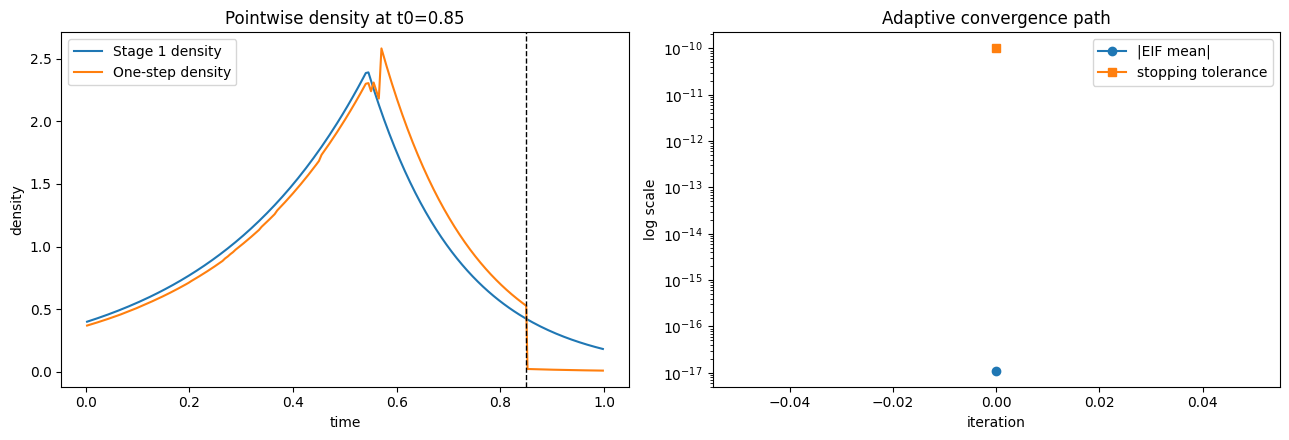

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(
    focus_one_step_fit['target_grid_midpoints'],
    focus_one_step_fit['density_before_grid'],
    label='Stage 1 density',
    color='tab:blue',
)
axes[0].plot(
    focus_one_step_fit['target_grid_midpoints'],
    focus_one_step_fit['estimated_density'],
    label='One-step density',
    color='tab:orange',
)
if focus_use_iterative and focus_final_state is not None:
    axes[0].plot(
        focus_final_state.grid_midpoints,
        focus_final_state.density_grid,
        label='Iterative density',
        color='tab:green',
    )
axes[0].axvline(FOCUS_T0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title(f'Pointwise density at t0={FOCUS_T0:.2f}')
axes[0].set_xlabel('time')
axes[0].set_ylabel('density')
axes[0].legend()

axes[1].plot(
    focus_history['iteration'],
    np.abs(focus_history['eif_mean']),
    marker='o',
    label='|EIF mean|',
)
axes[1].plot(
    focus_history['iteration'],
    focus_history['stop_tolerance'],
    marker='s',
    label='stopping tolerance',
)
axes[1].set_yscale('log')
axes[1].set_title('Adaptive convergence path')
axes[1].set_xlabel('iteration')
axes[1].set_ylabel('log scale')
axes[1].legend()

plt.tight_layout()
plt.show()

## Curve-Level Comparison

Now we run an adaptive rule over a small grid of target times:
- always run one-step first;
- iterate only when `abs(eif_mean_one_step) > ONE_STEP_EIF_GATE`.

This lets middle points stop immediately while keeping iterative updates available for difficult points.

In [8]:
curve_one_step = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=TARGET_TIMES,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=False,
)['summary'].copy()

curve_adaptive_summary, curve_adaptive_results = adaptive_iterate_tmle_curve(
    initial_fit=initial_fit,
    censoring_cache=censoring_cache,
    observed_data=data,
    one_step_summary=curve_one_step,
    eif_gate=ONE_STEP_EIF_GATE,
    survival_clip=SURVIVAL_CLIP,
    max_iter=MAX_ITER,
    min_abs_eps=MIN_ABS_EPS,
    min_score_tol=MIN_SCORE_TOL,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
)

curve_comparison = curve_one_step[
    ['t0', 'psi_init', 'psi_star', 'eif_mean', 'score_at_solution']
].rename(
    columns={
        'psi_star': 'psi_one_step',
        'eif_mean': 'eif_mean_one_step',
        'score_at_solution': 'score_at_solution_one_step',
    }
).merge(
    curve_adaptive_summary[
        ['t0', 'psi_star', 'eif_mean_final', 'n_iterations', 'stop_reason', 'used_iterative', 'decision_reason', 'one_step_abs_eif', 'one_step_eif_gate']
    ].rename(
        columns={
            'psi_star': 'psi_adaptive',
            'eif_mean_final': 'eif_mean_adaptive',
        }
    ),
    on='t0',
    how='left',
)
curve_comparison

,t0,psi_init,psi_one_step,eif_mean_one_step,score_at_solution_one_step,psi_adaptive,eif_mean_adaptive,n_iterations,stop_reason,used_iterative,decision_reason,one_step_abs_eif,one_step_eif_gate
0,0.001000,0.999602,1.000000e+00,1.843144e-19,4.607859e-18,1.000000e+00,1.843144e-19,0,one_step_gate,False,one_step_eif_below_gate,1.843144e-19,1.000000e-10
1,0.053526,0.976739,1.000000e+00,4.704570e-17,1.176143e-15,1.000000e+00,4.704570e-17,0,one_step_gate,False,one_step_eif_below_gate,4.704570e-17,1.000000e-10
2,0.106053,0.949522,1.000000e+00,1.582068e-17,3.955170e-16,1.000000e+00,1.582068e-17,0,one_step_gate,False,one_step_eif_below_gate,1.582068e-17,1.000000e-10
3,0.158579,0.917120,1.000000e+00,5.551115e-17,1.387779e-15,1.000000e+00,5.551115e-17,0,one_step_gate,False,one_step_eif_below_gate,5.551115e-17,1.000000e-10
4,0.211105,0.878548,1.000000e+00,1.443290e-17,3.608225e-16,1.000000e+00,1.443290e-17,0,one_step_gate,False,one_step_eif_below_gate,1.443290e-17,1.000000e-10
5,0.263632,0.832629,1.000000e+00,5.329071e-17,1.332268e-15,1.000000e+00,5.329071e-17,0,one_step_gate,False,one_step_eif_below_gate,5.329071e-17,1.000000e-10
6,0.316158,0.777964,1.000000e+00,-8.881784e-18,-2.220446e-16,1.000000e+00,-8.881784e-18,0,one_step_gate,False,one_step_eif_below_gate,8.881784e-18,1.000000e-10
7,0.368684,0.712888,8.266359e-01,2.799649e-14,6.999124e-13,8.266359e-01,2.799649e-14,0,one_step_gate,False,one_step_eif_below_gate,2.799649e-14,1.000000e-10
8,0.421211,0.635418,7.651336e-01,-7.522871e-15,-1.880718e-13,7.651336e-01,-7.522871e-15,0,one_step_gate,False,one_step_eif_below_gate,7.522871e-15,1.000000e-10
9,0.473737,0.543193,6.311458e-01,1.365574e-16,3.413936e-15,6.311458e-01,1.365574e-16,0,one_step_gate,False,one_step_eif_below_gate,1.365574e-16,1.000000e-10


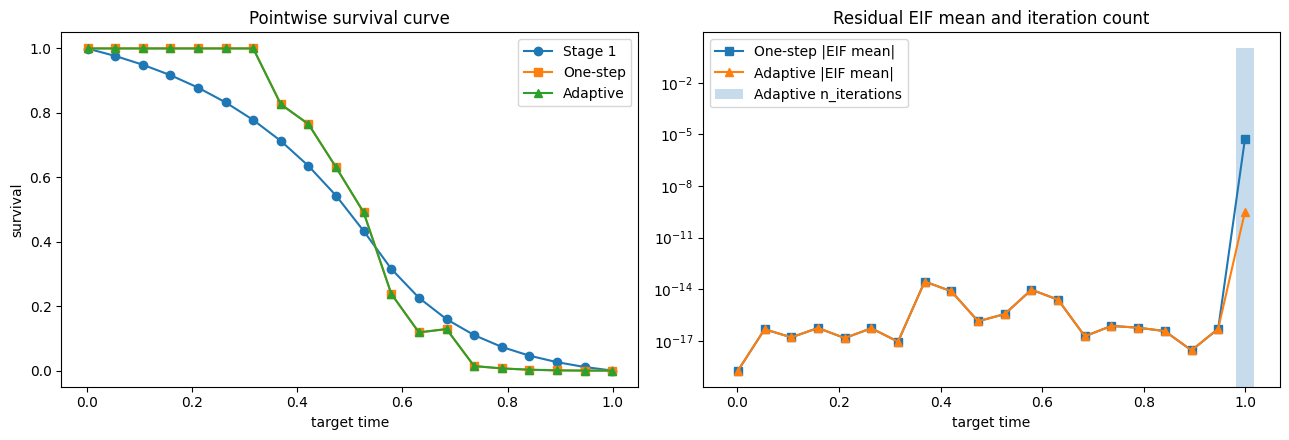

,t0,used_iterative,decision_reason,one_step_abs_eif,one_step_eif_gate,n_iterations,stop_reason,eif_mean_final
19,0.999000,True,one_step_eif_above_gate,5.131883e-06,1.000000e-10,1,score_tolerance,-3.112278e-10
0,0.001000,False,one_step_eif_below_gate,1.843144e-19,1.000000e-10,0,one_step_gate,1.843144e-19
1,0.053526,False,one_step_eif_below_gate,4.704570e-17,1.000000e-10,0,one_step_gate,4.704570e-17
2,0.106053,False,one_step_eif_below_gate,1.582068e-17,1.000000e-10,0,one_step_gate,1.582068e-17
3,0.158579,False,one_step_eif_below_gate,5.551115e-17,1.000000e-10,0,one_step_gate,5.551115e-17
4,0.211105,False,one_step_eif_below_gate,1.443290e-17,1.000000e-10,0,one_step_gate,1.443290e-17
5,0.263632,False,one_step_eif_below_gate,5.329071e-17,1.000000e-10,0,one_step_gate,5.329071e-17
6,0.316158,False,one_step_eif_below_gate,8.881784e-18,1.000000e-10,0,one_step_gate,-8.881784e-18
7,0.368684,False,one_step_eif_below_gate,2.799649e-14,1.000000e-10,0,one_step_gate,2.799649e-14
8,0.421211,False,one_step_eif_below_gate,7.522871e-15,1.000000e-10,0,one_step_gate,-7.522871e-15


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(curve_comparison['t0'], curve_comparison['psi_init'], marker='o', label='Stage 1')
axes[0].plot(curve_comparison['t0'], curve_comparison['psi_one_step'], marker='s', label='One-step')
axes[0].plot(curve_comparison['t0'], curve_comparison['psi_adaptive'], marker='^', label='Adaptive')
axes[0].set_title('Pointwise survival curve')
axes[0].set_xlabel('target time')
axes[0].set_ylabel('survival')
axes[0].legend()

axes[1].plot(curve_comparison['t0'], np.abs(curve_comparison['eif_mean_one_step']), marker='s', label='One-step |EIF mean|')
axes[1].plot(curve_comparison['t0'], np.abs(curve_comparison['eif_mean_adaptive']), marker='^', label='Adaptive |EIF mean|')
axes[1].bar(
    curve_adaptive_summary['t0'],
    curve_adaptive_summary['n_iterations'],
    width=0.035,
    alpha=0.25,
    label='Adaptive n_iterations',
)
axes[1].set_yscale('log')
axes[1].set_title('Residual EIF mean and iteration count')
axes[1].set_xlabel('target time')
axes[1].legend()

plt.tight_layout()
plt.show()

curve_adaptive_summary[
    ['t0', 'used_iterative', 'decision_reason', 'one_step_abs_eif', 'one_step_eif_gate', 'n_iterations', 'stop_reason', 'eif_mean_final']
].sort_values(['used_iterative', 't0'], ascending=[False, True])

## Notes

This notebook is intentionally a demo rather than a package interface.

What it establishes:
- one fixed augmented grid per `t0` is enough for the iterative outer loop;
- the mutable state can be carried entirely through density, log-density, and survival arrays on that grid;
- the outer stopping rule can be based on the empirical EIF mean;
- the tail can need more than one local TMLE update even when central points stop immediately.

If this behavior looks stable, the next step is to move these helpers into `learner.py` behind an `iterative=True` option while keeping the current one-step API as the default.